## 6 · EPPO Agent — soft decaying mask

The mask uses **exponential penalty decay** — not a hard binary block.

| Training phase | Penalty | Effect |
|----------------|---------|--------|
| Episode 0 | 1.5 | L2/L3 accessible; EPPO explores freely |
| Episode 500 | ~6.5 | Violations at ~0.15% probability |
| Episode 1500 | ~12.0 | Effectively blocked (<0.01%) |
| Episode 2500 | ~14.5 | Hard block equivalent |

This lets EPPO **discover that L2/L3 give better rewards early in training**, then gradually tightens the constraint so the final policy follows the mastery ladder. At evaluation and demo time, the hard mask is used.

The penalty is added to logits: `logits += soft_penalty_vector` where violations get a large negative value. L1 is never penalised (always available for remediation).


## 1 · Install

In [54]:
import subprocess
subprocess.run(['pip','install','sentence-transformers','scikit-learn','-q'],check=True)
print('Ready.')


Ready.


## 2 · Imports

In [55]:
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
from torch.distributions import Categorical
from collections import defaultdict
import os, warnings, matplotlib, matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.figsize'] = (16,4)
print(f'PyTorch {torch.__version__}  CUDA={torch.cuda.is_available()}')
if torch.cuda.is_available(): print(f'GPU: {torch.cuda.get_device_name(0)}')


PyTorch 2.10.0+cu128  CUDA=True
GPU: Tesla T4


## 3 · Config

Key mastery-progression parameters:

| Param | Value | Meaning |
|-------|-------|---------|
| `MASTERY_THRESHOLD` | 0.62 | PFA prediction must exceed this to count as 'passed' |
| `MIN_ATTEMPTS` | 3 | Min questions at a level before advance is allowed |
| `TARGET_LEVEL` | 3 | Session goal: L3 (Apply) mastered on all concepts |
| `REMEDIATION_STEPS` | 12 | Extra steps after main loop for weak concepts |
| `STATE_DIM` | 72 | 9 features × 8 concepts (richer than old 32-dim) |


In [56]:
class Config:
    CONCEPTS = [
        'binary search tree', 'linked list', 'sorting algorithms',
        'dynamic programming', 'process scheduling', 'memory management',
        'TCP IP basics', 'recursion',
    ]
    N_CONCEPTS   = len(CONCEPTS)
    BLOOM_LEVELS = 6
    N_ACTIONS    = N_CONCEPTS * BLOOM_LEVELS  # 48

    # ── Mastery model ────────────────────────────────────────────────────
    TARGET_LEVEL       = 3     # conceptual target level (L3 = Apply)
                               # mastery is scored continuously via BLOOM_WEIGHTS
                               # this is used for display and gate logic only
    # Concept mastery = weighted mean of PFA predictions across all 6 levels
    # subject to L3/L4 gate and visit requirements.
    # This reflects: student should be intermediate-level with fair exposure
    # to all levels, not just binary pass/fail per level.
    BLOOM_WEIGHTS      = np.array([0.10, 0.15, 0.20, 0.25, 0.20, 0.10])
    L3L4_FLOOR         = 0.42  # min PFA at L3 AND L4 to pass intermediate gate
    MIN_VISIT          = 2     # min attempts needed at L3/L4 before gate is tested
    CONCEPT_FLOOR      = 0.42  # each concept must reach at least this mastery score
    SESSION_MASTERY_GOAL = 0.58 # mean concept mastery score to end session early

    # ── Session length — scales with concept count ────────────────────────
    # Each concept needs ~12 interactions to show meaningful L1-L4 progress.
    # This scales automatically when N_CONCEPTS changes (e.g. 8 → 40).
    STEPS_PER_CONCEPT  = 12    # base interactions per concept per session
    BASE_STEPS         = N_CONCEPTS * STEPS_PER_CONCEPT  # 96 for 8 concepts
    MIN_STEPS_PER_CONCEPT = 5  # floor: each concept gets at least 5 steps
    MIN_STEPS          = N_CONCEPTS * MIN_STEPS_PER_CONCEPT  # 40 for 8
    REMEDIATION_FRAC   = 0.20  # remediation = 20% of ep_max_steps

    # ── Multi-session design ─────────────────────────────────────────────
    # Students realistically need multiple sessions to reach mastery.
    # Sessions end on MAX STEPS or PLATEAU — not on goal reached.
    # The goal is a reward milestone, not a termination condition.
    PLATEAU_WINDOW     = 20    # steps to look back for plateau detection
    PLATEAU_THRESHOLD  = 0.008 # improvement needed over window to avoid plateau
    # At ~0.003 gain/step, a healthy session needs at least 0.008 over 20 steps
    # to avoid false-positive plateau. Set high enough to allow L1 drilling
    # to register as progress.
    # Milestone bonuses (fire once per episode when score crosses each level)
    # Milestone thresholds (mean mastery score, calibrated to PFA ranges):
    MILESTONE_1        = 0.25  # cold start crossed (L1 partially seen)
    MILESTONE_2        = 0.32  # L1 solid, L2 started
    MILESTONE_3        = 0.40  # L1+L2 good, L3 started
    W_MILESTONE        = 3.0   # reward per milestone crossed

    # ── PFA ───────────────────────────────────────────────────────────────
    PFA_TOP_K   = 3
    PFA_ALPHA   = 0.05
    BETA_LEVEL  = np.array([-0.3, -0.8, -1.4, -2.0, -2.6, -3.2])
    GAMMA_LEVEL = np.array([ 0.40,  0.36,  0.32,  0.28,  0.24,  0.20])
    RHO_LEVEL   = np.array([ 0.18,  0.22,  0.28,  0.35,  0.43,  0.52])

    # ── Student ───────────────────────────────────────────────────────────
    SLIP           = 0.08
    GUESS          = 0.15
    LEARN_RATE     = 0.04
    FORGET_RATE    = 0.005
    TRANSFER_ALPHA = 0.30

    # ── EPPO ──────────────────────────────────────────────────────────────
    # 9 features per concept:
    #   pfa_L1..L3, attempts_L1..L3, mastered_L1..L3 (binary)
    STATE_DIM    = N_CONCEPTS * 9  # 72
    HIDDEN_DIM   = 256             # larger: richer state needs more capacity
    LR_ACTOR     = 3e-4
    LR_CRITIC    = 1e-3
    GAMMA        = 0.99
    GAE_LAMBDA   = 0.95
    CLIP_EPS     = 0.20
    ENTROPY_COEF = 0.05   # raised: prevents policy collapse (was 0.02, collapsed to 0.005)
    VALUE_COEF   = 0.50
    PPO_EPOCHS   = 4
    GRAD_CLIP    = 0.50

    # ── Soft mask decay (exploration → exploitation) ──────────────────
    # Early training: small penalty → EPPO can explore L2/L3 freely
    # Late training: large penalty → mask tightens to enforce ladder
    # This lets EPPO discover that higher levels give better reward
    # before the curriculum constraint fully kicks in.
    MASK_PENALTY_START = 0.5    # very soft start — EPPO explores freely early
    MASK_PENALTY_END   = 12.0   # near-hard-block at end of training
    MASK_DECAY_RATE    = 0.0008 # 3x slower than before
    # penalty(ep) = END - (END-START)*exp(-DECAY_RATE * ep)
    # At ep=0:    penalty ≈ 0.5  → all levels roughly accessible
    # At ep=500:  penalty ≈ 3.8  → violations at ~2% probability
    # At ep=1000: penalty ≈ 6.5  → violations at ~0.15% probability
    # At ep=2000: penalty ≈ 10.2 → effectively blocked
    # At ep=2500: penalty ≈ 11.4 → hard block equivalent

    # ── Training ──────────────────────────────────────────────────────────
    WARMUP_EPISODES = 300
    N_EPISODES      = 2500
    LOG_EVERY       = 100
    SAVE_EVERY      = 500

    # ── Student session sampling ──────────────────────────────────────────
    # In reality students have multiple sessions. To teach EPPO to handle
    # returning students (partial prior mastery), we sample 3 student types:
    #
    #   fresh     (40%): cold start, no prior — first ever session
    #   returning (40%): had 1-2 prior sessions — partial mastery already built
    #   advanced  (20%): high ability — shows EPPO what capable students look like
    #
    # A 'returning' student is simulated by pre-running N_PRIOR_STEPS random
    # interactions before the episode starts, so the PFA tracker reflects
    # prior learning and EPPO sees a non-cold-start state.
    PRIOR_STEPS_MIN  = 20   # min prior interactions for returning student
    PRIOR_STEPS_MAX  = 60   # max prior interactions for returning student
    STUDENT_TYPE_P   = [0.40, 0.40, 0.20]  # fresh / returning / advanced

    # ── Reward weights ────────────────────────────────────────────────────
    W_MASTERY_DELTA = 4.0   # weighted mastery-score improvement × N_CONCEPTS
    W_PROGRESSION   = 1.0   # correct at level k × BLOOM_WEIGHTS[k]
    W_GATE_PENALTY  = 1.5   # penalty for drilling L1/L2 when L3/L4 neglected
    W_FIXATION      = 0.5   # penalty: same concept 3+ times in last 4 steps
    W_COVERAGE      = 0.6   # bonus: first visit to a concept this episode
    W_COMPLETION    = 10.0  # bonus: session mastery goal reached
    W_APR           = 1.0   # broad APR gain signal

    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # ── Backward-compat aliases (used in PFATracker + mask logic) ────────
    MASTERY_THRESHOLD = L3L4_FLOOR
    MIN_ATTEMPTS      = MIN_VISIT
    MAX_STEPS         = BASE_STEPS
    REMEDIATION_STEPS = int(BASE_STEPS * REMEDIATION_FRAC)


cfg = Config()
print(f'Concepts : {cfg.N_CONCEPTS}')
print(f'Actions  : {cfg.N_ACTIONS}')
print(f'State dim: {cfg.STATE_DIM}  (9 features x {cfg.N_CONCEPTS} concepts)')
print(f'Target   : L{cfg.TARGET_LEVEL} mastered on all {cfg.N_CONCEPTS} concepts')
print(f'Device   : {cfg.DEVICE}')


Concepts : 8
Actions  : 48
State dim: 72  (9 features x 8 concepts)
Target   : L3 mastered on all 8 concepts
Device   : cuda


## 4 · PFA Knowledge Tracer

Extended with mastery tracking per concept × level:
- `attempts[c, k]` — how many times concept c at level k has been attempted
- `mastered[c, k]` — True when PFA prediction > MASTERY_THRESHOLD AND attempts >= MIN_ATTEMPTS

The state vector is now **72-dim** (9 features × 8 concepts):
`[pfa_L1, pfa_L2, pfa_L3, att_L1, att_L2, att_L3, mast_L1, mast_L2, mast_L3]` per concept.
Only L1–L3 are in the state because TARGET_LEVEL=3 — higher levels are tracked but not in state.


In [57]:
class PFATracker:

    def __init__(self, concepts, cfg, sim_matrix=None):
        self.concepts     = concepts
        self.cfg          = cfg
        self.num_levels   = cfg.BLOOM_LEVELS
        self.num_concepts = len(concepts)
        self.idx          = {c: i for i, c in enumerate(concepts)}

        self.successes         = np.zeros((self.num_concepts, self.num_levels))
        self.failures          = np.zeros((self.num_concepts, self.num_levels))
        self.propagation_bonus = np.zeros((self.num_concepts, self.num_levels))
        self.attempts          = np.zeros((self.num_concepts, self.num_levels), dtype=int)
        self.mastered          = np.zeros((self.num_concepts, self.num_levels), dtype=bool)

        rng_prior         = np.random.default_rng(42)
        self.beta_concept = rng_prior.uniform(-0.3, 0.3, self.num_concepts)

        if sim_matrix is not None:
            self.sim_matrix = sim_matrix
            self._build_neighbors()
        else:
            self._build_similarity_graph()

    def _build_similarity_graph(self):
        print('  Building similarity graph...')
        from sentence_transformers import SentenceTransformer
        model = SentenceTransformer('BAAI/bge-base-en-v1.5')
        emb = model.encode(self.concepts, normalize_embeddings=True)
        self.sim_matrix = emb @ emb.T
        self._build_neighbors()
        print(f"  Done. Top-3 of '{self.concepts[0]}':")
        for j in self.neighbors[0]:
            print(f'    {self.concepts[j]}  {self.sim_matrix[0,j]:.3f}')

    def _build_neighbors(self):
        self.neighbors = []
        for i in range(self.num_concepts):
            ranked = np.argsort(-self.sim_matrix[i])
            self.neighbors.append([j for j in ranked if j != i][:self.cfg.PFA_TOP_K])

    def predict(self, concept, level):
        i, k = self.idx[concept], level - 1
        cfg  = self.cfg
        z = (
            self.beta_concept[i]
            + cfg.BETA_LEVEL[k]
            + cfg.GAMMA_LEVEL[k] * np.log1p(self.successes[i, k])
            - cfg.RHO_LEVEL[k]   * np.log1p(self.failures[i, k])
            + self.propagation_bonus[i, k]
        )
        if k > 0:
            z += 0.25 * (
                cfg.GAMMA_LEVEL[k-1] * np.log1p(self.successes[i, k-1])
                - cfg.RHO_LEVEL[k-1] * np.log1p(self.failures[i, k-1])
            )
        raw = float(1 / (1 + np.exp(-z)))
        return float(np.clip(raw, cfg.GUESS, 1.0 - cfg.SLIP))

    def predict_idx(self, ci, level):
        return self.predict(self.concepts[ci], level)

    def update(self, concept, level, correct):
        i, k = self.idx[concept], level - 1
        self.attempts[i, k] += 1
        old_p = self.predict(concept, level)
        if correct:
            self.successes[i, k] += 1
        else:
            self.failures[i, k] += 1
        delta = np.clip(self.predict(concept, level) - old_p, -0.10, 0.10)
        for j in self.neighbors[i]:
            sim = self.sim_matrix[i, j]
            for lvl in range(k + 1):
                self.propagation_bonus[j, lvl] += self.cfg.PFA_ALPHA * sim / (lvl + 1) * delta
        # Update mastery flag
        p = self.predict(concept, level)
        if p >= self.cfg.MASTERY_THRESHOLD and self.attempts[i, k] >= self.cfg.MIN_ATTEMPTS:
            self.mastered[i, k] = True

    def update_idx(self, ci, level, correct):
        self.update(self.concepts[ci], level, correct)

    def is_mastered(self, ci, level):
        return bool(self.mastered[ci, level - 1])

    def current_level(self, ci):
        # Highest level where all previous levels are mastered
        for k in range(self.cfg.BLOOM_LEVELS - 1, -1, -1):
            if self.mastered[ci, k]:
                return k + 1
        return 1


    def get_state_vector(self):
        # 9 features per concept:
        #  [pfa_L1, pfa_L2, pfa_L3, pfa_L4,   <- PFA predictions
        #   att_L1, att_L2, att_L3, att_L4,   <- normalised attempt counts
        #   mastery_score]                     <- weighted concept mastery
        # Total: 9 x N_CONCEPTS = 72 dim (unchanged)
        feats = []
        for i, c in enumerate(self.concepts):
            pfa  = [self.predict(c, l+1) for l in range(4)]
            att  = [min(self.attempts[i, l] / 10.0, 1.0) for l in range(4)]
            ms   = [self.concept_mastery_score(i)]
            feats.extend(pfa + att + ms)
        return np.array(feats, dtype=np.float32)

    def get_mastery_matrix(self):
        M = np.zeros((self.num_concepts, self.num_levels))
        for i, c in enumerate(self.concepts):
            for k in range(self.num_levels):
                M[i, k] = self.predict(c, k + 1)
        return M

    def concept_mastery_score(self, ci):
        """
        Full weighted mean of PFA across all 6 Bloom levels.

        score = dot(BLOOM_WEIGHTS, [pfa_L1..pfa_L6])

        Unvisited levels contribute their PFA prior (~0.15-0.25),
        which is naturally low — EPPO must visit higher levels to
        improve the score beyond L1+L2 drilling ceiling (~0.28).

        Calibrated score ranges:
          Cold start:              ~0.18-0.22
          L1 well-mastered:        ~0.22-0.28
          L1+L2 decent:            ~0.28-0.36
          L1+L2+L3 intermediate:   ~0.36-0.46
          L1-L4 above 0.55:        ~0.46-0.60

        L3/L4 gate: when both visited and both below L3L4_FLOOR, cap at 0.34.
        Advanced bonus: visited L5/L6 above 0.55 adds +0.03 each.
        """
        cfg  = self.cfg
        pfa  = np.array([self.predict(self.concepts[ci], k+1)
                         for k in range(self.num_levels)])
        base = float(np.dot(cfg.BLOOM_WEIGHTS, pfa))

        # L3/L4 gate
        l3_vis = self.attempts[ci, 2] >= cfg.MIN_VISIT
        l4_vis = self.attempts[ci, 3] >= cfg.MIN_VISIT
        if l3_vis and l4_vis:
            if pfa[2] < cfg.L3L4_FLOOR and pfa[3] < cfg.L3L4_FLOOR:
                base = min(base, 0.34)

        # Advanced bonus
        for k in [4, 5]:
            if self.attempts[ci, k] >= cfg.MIN_VISIT and pfa[k] > 0.55:
                base = min(base + 0.03, 1.0)

        return float(np.clip(base, 0.0, 1.0))

    def mean_mastery_score(self):
        return float(np.mean([self.concept_mastery_score(ci)
                              for ci in range(self.num_concepts)]))

    def session_success(self):
        """
        Session success: all concepts have a visited-normalised score
        above CONCEPT_FLOOR AND mean score >= SESSION_MASTERY_GOAL.

        Both thresholds are against visited-normalised scores, so they
        are achievable as soon as the student has answered enough questions
        at the right levels.
        """
        scores = [self.concept_mastery_score(ci)
                  for ci in range(self.num_concepts)]
        return (
            float(np.mean(scores)) >= self.cfg.SESSION_MASTERY_GOAL
            and all(s >= self.cfg.CONCEPT_FLOOR for s in scores)
        )

    def all_mastered_to_target(self):
        # Legacy name — now delegates to session_success
        return self.session_success()

    def reset(self):
        self.successes[:] = 0; self.failures[:] = 0
        self.propagation_bonus[:] = 0; self.attempts[:] = 0
        self.mastered[:] = False


print('PFATracker defined.')


PFATracker defined.


## 5 · Realistic Student Simulator

In [58]:
class RealisticStudent:

    def __init__(self, concepts, sim_matrix, rng, cfg):
        self.concepts = concepts; self.sim_matrix = sim_matrix
        self.rng = rng; self.slip = cfg.SLIP; self.guess = cfg.GUESS
        self.learn_rate = cfg.LEARN_RATE; self.forget_rate = cfg.FORGET_RATE
        self.transfer_alpha = cfg.TRANSFER_ALPHA
        num_c = len(concepts)
        base  = rng.uniform(-1.5, 0.5, size=num_c)
        lo    = np.array([1.0, 0.6, 0.2, -0.2, -0.7, -1.3])
        self.ability         = base[:, None] + lo[None, :]
        self.item_difficulty = np.array([0.0, 0.5, 1.0, 1.5, 2.2, 3.0])
        self.last_attempt    = defaultdict(lambda: 0)
        self.t               = 0

    @classmethod
    def from_archetype(cls, concepts, sim_matrix, rng, cfg, archetype='mixed'):
        s = cls(concepts, sim_matrix, rng, cfg)
        ranges = {'beginner':(-1.8,-0.5),'intermediate':(-0.8,0.3),
                  'advanced':(-0.2,1.0),'mixed':(-1.5,0.5)}
        lo, hi = ranges.get(archetype, (-1.5, 0.5))
        base   = rng.uniform(lo, hi, size=len(concepts))
        loff   = np.array([1.0, 0.6, 0.2, -0.2, -0.7, -1.3])
        s.ability = base[:, None] + loff[None, :]
        return s

    def _apply_forgetting(self, ci, k):
        elapsed = self.t - self.last_attempt[(ci, k)]
        if elapsed > 0:
            self.ability[ci, k] = max(self.ability[ci, k] - self.cfg.FORGET_RATE * np.sqrt(elapsed), -3.0)

    # Attach cfg so forgetting can use it
    def answer(self, ci, level):
        self.t += 1; k = level - 1
        self._apply_forgetting(ci, k)
        logit  = self.ability[ci, k] - self.item_difficulty[k]
        p_know = float(1 / (1 + np.exp(-logit)))
        true_p = self.guess + (1 - self.slip - self.guess) * p_know
        correct = bool(self.rng.random() < true_p)
        self.last_attempt[(ci, k)] = self.t
        return correct, true_p, p_know

    def learn(self, ci, level, correct):
        k = level - 1
        if correct:
            self.ability[ci, k] += self.learn_rate
            if k > 0: self.ability[ci, k-1] += self.learn_rate * 0.3
        else:
            self.ability[ci, k] = max(self.ability[ci, k] - self.learn_rate * 0.3, -3.0)
        for j, sim in enumerate(self.sim_matrix[ci]):
            if j == ci or sim < 0.50: continue
            self._apply_forgetting(j, k)
            if correct: self.ability[j, k] += self.transfer_alpha * sim * self.learn_rate


# Attach cfg reference after the fact so forget works
RealisticStudent.cfg = None
def _rs_init_patch(self, concepts, sim_matrix, rng, cfg):
    self.concepts = concepts; self.sim_matrix = sim_matrix
    self.rng = rng; self.slip = cfg.SLIP; self.guess = cfg.GUESS
    self.learn_rate = cfg.LEARN_RATE; self.forget_rate = cfg.FORGET_RATE
    self.transfer_alpha = cfg.TRANSFER_ALPHA; self.cfg = cfg
    num_c = len(concepts)
    base  = rng.uniform(-1.5, 0.5, size=num_c)
    lo    = np.array([1.0, 0.6, 0.2, -0.2, -0.7, -1.3])
    self.ability         = base[:, None] + lo[None, :]
    self.item_difficulty = np.array([0.0, 0.5, 1.0, 1.5, 2.2, 3.0])
    self.last_attempt    = defaultdict(lambda: 0)
    self.t               = 0
RealisticStudent.__init__ = _rs_init_patch
print('RealisticStudent defined.')


RealisticStudent defined.


## 6 · EPPO Agent — mastery-gated action mask

The action mask now enforces the mastery ladder:

| Condition | Allowed levels |
|-----------|---------------|
| L1 not mastered | L1 only |
| L1 mastered, L2 not | L1, L2 |
| L2 mastered, L3 not | L1, L2, L3 |
| L3 mastered | L1, L2, L3, L4 |

L1 is always allowed (remediation). EPPO decides whether to drill, advance, or remediate.


In [59]:
class EPPOAgent(nn.Module):

    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.current_episode = 0  # updated by train() each episode
        self.actor = nn.Sequential(
            nn.Linear(cfg.STATE_DIM, cfg.HIDDEN_DIM), nn.LayerNorm(cfg.HIDDEN_DIM), nn.ReLU(),
            nn.Linear(cfg.HIDDEN_DIM, cfg.HIDDEN_DIM), nn.LayerNorm(cfg.HIDDEN_DIM), nn.ReLU(),
            nn.Linear(cfg.HIDDEN_DIM, cfg.N_ACTIONS),
        )
        self.critic = nn.Sequential(
            nn.Linear(cfg.STATE_DIM, cfg.HIDDEN_DIM), nn.LayerNorm(cfg.HIDDEN_DIM), nn.ReLU(),
            nn.Linear(cfg.HIDDEN_DIM, cfg.HIDDEN_DIM), nn.LayerNorm(cfg.HIDDEN_DIM), nn.ReLU(),
            nn.Linear(cfg.HIDDEN_DIM, 1),
        )

    def _mask_penalty(self):
        # Exponential growth: small early (exploration) → large late (exploitation)
        cfg = self.cfg
        ep  = self.current_episode
        penalty = cfg.MASK_PENALTY_END - (
            (cfg.MASK_PENALTY_END - cfg.MASK_PENALTY_START)
            * np.exp(-cfg.MASK_DECAY_RATE * ep)
        )
        return float(penalty)

    def get_soft_violation_mask(self, tracker):
        # Returns a float tensor: 0.0 for legal actions, -penalty for violations.
        # NOT a hard binary block — EPPO can still explore violations early in training.
        cfg     = self.cfg
        penalty = self._mask_penalty()
        soft    = torch.zeros(cfg.N_ACTIONS)  # 0 = no penalty
        for c in range(cfg.N_CONCEPTS):
            for k in range(1, cfg.BLOOM_LEVELS):
                prev_mastered  = bool(tracker.mastered[c, k-1])
                prev_attempted = tracker.attempts[c, k-1] >= cfg.MIN_ATTEMPTS
                if not prev_mastered and not prev_attempted:
                    # Violation: previous level not ready
                    # Apply penalty to this AND all higher levels
                    for kk in range(k, cfg.BLOOM_LEVELS):
                        soft[c * cfg.BLOOM_LEVELS + kk] = -penalty
                    break
        # L1 never penalised (always available for remediation)
        for c in range(cfg.N_CONCEPTS):
            soft[c * cfg.BLOOM_LEVELS] = 0.0
        return soft

    def get_action_mask(self, tracker):
        # Hard mask only for actions that are completely unreachable
        # (late training equivalent, used for evaluation/demo after training)
        cfg  = self.cfg
        mask = torch.zeros(cfg.N_ACTIONS, dtype=torch.bool)
        for c in range(cfg.N_CONCEPTS):
            mask[c * cfg.BLOOM_LEVELS] = True
            for k in range(1, cfg.BLOOM_LEVELS):
                prev_mastered  = bool(tracker.mastered[c, k-1])
                prev_attempted = tracker.attempts[c, k-1] >= cfg.MIN_ATTEMPTS
                if prev_mastered or prev_attempted:
                    mask[c * cfg.BLOOM_LEVELS + k] = True
                else:
                    break
        return mask

    def select_action(self, state, tracker, training=True):
        state_t  = torch.FloatTensor(state).to(self.cfg.DEVICE)
        logits   = self.actor(state_t)
        if training:
            # Soft penalty during training: decays from permissive to strict
            soft_pen = self.get_soft_violation_mask(tracker).to(self.cfg.DEVICE)
            logits   = logits + soft_pen
        else:
            # Hard mask at evaluation/demo: fully enforce the ladder
            mask   = self.get_action_mask(tracker).to(self.cfg.DEVICE)
            logits = logits.masked_fill(~mask, float('-inf'))
        dist   = Categorical(logits=logits)
        action = dist.sample()
        return action.item(), dist.log_prob(action).item(), dist.entropy().item(), self.critic(state_t).item()

    def evaluate(self, states, actions):
        logits = self.actor(states).clamp(min=-1e9)
        values = self.critic(states).squeeze(1)
        dist   = Categorical(logits=logits)
        return dist.log_prob(actions), values, dist.entropy()


print('EPPOAgent defined.')


EPPOAgent defined.


## 7 · Reward — mastery-aligned

| Term | Trigger | Value |
|------|---------|-------|
| R1 mastery event | PFA crosses MASTERY_THRESHOLD at any level | +W_MASTERY_EVENT |
| R2 progression | Correct at L2+ | +W_PROGRESSION × (level-1) |
| R3 wrong order | Tried L(k+1) when L(k) not mastered AND < MIN_ATTEMPTS | −W_WRONG_ORDER |
| R4 idle | Step on already-mastered concept at already-mastered level | −W_IDLE |
| R5 completion | All concepts mastered to TARGET_LEVEL | +W_COMPLETION |
| R6 APR gain | Mean L1 prediction improvement | +W_APR × gain × N |


In [60]:
def compute_reward(tracker_before_scores, tracker, ci, level, correct,
                   mastery_before, mastery_after, cfg,
                   action_history, concepts_visited, milestones_hit):
    """
    Reward aligned to multi-session mastery-progression model.

    R1 — weighted mastery-score delta (main learning signal)
    R2 — level-weighted progression bonus (higher Bloom = more reward)
    R3 — intermediate gate penalty (forces L3/L4 visit after L1/L2 saturation)
    R4 — concept fixation penalty (keeps coverage broad)
    R5 — milestone bonuses (fires when mean score crosses 0.45/0.55/0.65)
         rewards progress-toward-goal, not only goal completion
    R6 — broad APR signal
    R7 — coverage bonus (first visit per concept per session)
    """
    k = level - 1

    # R1 — weighted mastery-score improvement for this concept
    score_before = tracker_before_scores[ci]
    score_after  = tracker.concept_mastery_score(ci)
    delta        = score_after - score_before
    R1 = float(np.clip(cfg.W_MASTERY_DELTA * delta * cfg.N_CONCEPTS, -4.0, 8.0))

    # R2 — level-weighted correct answer
    R2 = cfg.W_PROGRESSION * float(cfg.BLOOM_WEIGHTS[k]) * 6 if correct else 0.0

    # R3 — gate penalty: still drilling L1/L2 after 8+ attempts without
    # visiting L3/L4 (only fires when agent is actively avoiding advancement)
    l3_visited   = tracker.attempts[ci, 2] >= cfg.MIN_VISIT
    l4_visited   = tracker.attempts[ci, 3] >= cfg.MIN_VISIT
    shallow      = level <= 2 and not l3_visited and not l4_visited
    long_session = sum(1 for a in action_history
                       if a // cfg.BLOOM_LEVELS == ci) >= 8
    R3 = -cfg.W_GATE_PENALTY if shallow and long_session else 0.0

    # R4 — concept fixation penalty
    recent          = action_history[-4:] if len(action_history) >= 4 else action_history
    recent_concepts = [a // cfg.BLOOM_LEVELS for a in recent]
    fixation_count  = recent_concepts.count(ci)
    R4 = -cfg.W_FIXATION * fixation_count if fixation_count >= 3 else 0.0

    # R5 — milestone bonuses (replaces all-or-nothing completion bonus)
    # Fires when mean mastery score crosses 0.45, 0.55, or 0.65.
    # Rewards progress-toward-goal every session, not just successful ones.
    # milestones_hit is a set — each milestone fires at most once per episode.
    mean_score = tracker.mean_mastery_score()
    R5 = 0.0
    for milestone in [cfg.MILESTONE_1, cfg.MILESTONE_2, cfg.MILESTONE_3]:
        if mean_score >= milestone and milestone not in milestones_hit:
            R5 += cfg.W_MILESTONE
            milestones_hit.add(milestone)

    # R6 — broad APR signal
    apr_gain = float(np.mean(mastery_after[:, 0])) - float(np.mean(mastery_before[:, 0]))
    R6 = float(np.clip(cfg.W_APR * apr_gain * cfg.N_CONCEPTS, -3.0, 5.0))

    # R7 — coverage: first visit to this concept this episode
    R7 = cfg.W_COVERAGE if ci not in concepts_visited else 0.0

    return float(R1 + R2 + R3 + R4 + R5 + R6 + R7)


print('compute_reward defined.')


compute_reward defined.


## 8 · Rollout buffer · GAE · PPO update

In [61]:
class RolloutBuffer:
    def __init__(self):
        self.states=[]; self.actions=[]; self.log_probs=[]
        self.rewards=[]; self.values=[]; self.entropies=[]; self.dones=[]
    def store(self,s,a,lp,r,v,e,d):
        self.states.append(s); self.actions.append(a); self.log_probs.append(lp)
        self.rewards.append(r); self.values.append(v)
        self.entropies.append(e); self.dones.append(d)
    def clear(self): self.__init__()
    def __len__(self): return len(self.states)
    def get_tensors(self, device):
        return (
            torch.FloatTensor(np.array(self.states)).to(device),
            torch.LongTensor(self.actions).to(device),
            torch.FloatTensor(self.log_probs).to(device),
            torch.FloatTensor(self.rewards).to(device),
            torch.FloatTensor(self.values).to(device),
            torch.FloatTensor(self.entropies).to(device),
            torch.FloatTensor(self.dones).to(device),
        )


def compute_gae(rewards, values, dones, gamma, lam):
    advantages = []; gae = 0.0; next_val = 0.0
    for t in reversed(range(len(rewards))):
        delta = rewards[t] + gamma * next_val * (1 - dones[t]) - values[t]
        gae   = delta + gamma * lam * (1 - dones[t]) * gae
        advantages.insert(0, gae)
        next_val = values[t]
    adv = torch.FloatTensor(advantages)
    return adv, adv + torch.FloatTensor(values)


def ppo_update(agent, buffer, actor_opt, critic_opt, cfg):
    states, actions, old_lp, rewards, values, stored_ent, dones = \
        buffer.get_tensors(cfg.DEVICE)
    advantages, returns = compute_gae(
        rewards.cpu().numpy(), values.cpu().numpy(),
        dones.cpu().numpy(), cfg.GAMMA, cfg.GAE_LAMBDA)
    returns    = returns.to(cfg.DEVICE)
    advantages = advantages.to(cfg.DEVICE)
    ret_mean   = returns.mean().detach()
    ret_std    = returns.std().detach() + 1e-8
    returns_n  = (returns - ret_mean) / ret_std
    adv_norm   = (advantages - advantages.mean()) / (advantages.std() + 1e-8) \
                 if advantages.numel() > 1 else advantages
    total_al = total_cl = total_ent = 0.0
    for _ in range(cfg.PPO_EPOCHS):
        new_lp, new_vals, new_ent = agent.evaluate(states, actions)
        ratio  = torch.exp(new_lp - old_lp.detach())
        surr1  = ratio * adv_norm
        surr2  = torch.clamp(ratio, 1-cfg.CLIP_EPS, 1+cfg.CLIP_EPS) * adv_norm
        a_loss = -torch.min(surr1, surr2).mean()
        c_loss = nn.MSELoss()(new_vals, returns_n)
        loss   = a_loss + cfg.VALUE_COEF * c_loss - cfg.ENTROPY_COEF * stored_ent.mean()
        actor_opt.zero_grad(); critic_opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(agent.parameters(), cfg.GRAD_CLIP)
        actor_opt.step(); critic_opt.step()
        total_al += a_loss.item(); total_cl += c_loss.item()
        total_ent += new_ent.mean().item()
    n = cfg.PPO_EPOCHS
    return total_al/n, total_cl/n, total_ent/n


print('Buffer, GAE, PPO defined.')


Buffer, GAE, PPO defined.


## 9 · PFA validation — 8-test suite

In [62]:
def run_pfa_validation(cfg, sim_matrix, rng):
    from sklearn.metrics import roc_auc_score
    print('\n' + '='*55)
    print('  PFA VALIDATION (8 tests)')
    print('='*55)
    probe = cfg.CONCEPTS[0]; results = {}
    def fresh(): return PFATracker(cfg.CONCEPTS, cfg, sim_matrix=sim_matrix)
    def make_s(): return RealisticStudent(cfg.CONCEPTS, sim_matrix, rng, cfg)

    # T1
    t, s = fresh(), make_s(); preds = []
    for _ in range(60): preds.append(t.predict(probe,1)); t.update(probe,1,True); s.learn(t.idx[probe],1,True)
    drops = sum(1 for a,b in zip(preds,preds[1:]) if b < a-1e-9)
    gain  = preds[-1]-preds[0]; t1 = drops==0 and gain>0.05
    print(f'  T1 always-correct: {preds[0]:.3f}->{preds[-1]:.3f}  {"PASS" if t1 else "FAIL"}')
    results['t1'] = t1

    # T2
    t, s = fresh(), make_s(); preds = []
    for _ in range(60): preds.append(t.predict(probe,1)); t.update(probe,1,False); s.learn(t.idx[probe],1,False)
    rises = sum(1 for a,b in zip(preds,preds[1:]) if b > a+1e-9)
    drop  = preds[0]-preds[-1]; t2 = rises==0 and drop>0.05
    print(f'  T2 always-wrong:   {preds[0]:.3f}->{preds[-1]:.3f}  {"PASS" if t2 else "FAIL"}')
    results['t2'] = t2

    # T3
    t, s = fresh(), make_s(); ci = t.idx[probe]
    for k in range(cfg.BLOOM_LEVELS):
        for _ in range(40): t.update(probe,k+1,True); s.learn(ci,k+1,True)
    fp=[t.predict(probe,l+1) for l in range(cfg.BLOOM_LEVELS)]
    t3 = all(a>=b for a,b in zip(fp,fp[1:]))
    print(f'  T3 bloom order:    {[f"{p:.2f}" for p in fp]}  {"PASS" if t3 else "FAIL"}')
    results['t3'] = t3

    # T4
    t, s = fresh(), make_s(); y_true, y_pred = [], []
    for _ in range(1500):
        c_name=rng.choice(cfg.CONCEPTS); ci=t.idx[c_name]; lvl=int(rng.integers(1,cfg.BLOOM_LEVELS+1))
        correct,_,_ = s.answer(ci,lvl)
        y_pred.append(t.predict(c_name,lvl)); y_true.append(int(correct))
        t.update(c_name,lvl,correct); s.learn(ci,lvl,correct)
    y_true=np.array(y_true); y_pred=np.array(y_pred)
    ece=sum((((y_pred>=i/10)&(y_pred<(i+1)/10)).sum()/len(y_pred))
            *abs(y_true[(y_pred>=i/10)&(y_pred<(i+1)/10)].mean()-y_pred[(y_pred>=i/10)&(y_pred<(i+1)/10)].mean())
            for i in range(10) if ((y_pred>=i/10)&(y_pred<(i+1)/10)).sum()>0)
    auc=roc_auc_score(y_true,y_pred); t4=ece<0.10
    print(f'  T4 calibration:    ECE={ece:.4f} AUC={auc:.3f}  {"PASS" if t4 else "FAIL"}')
    results.update({'t4':t4,'ece':ece,'auc':auc})

    # T5
    t,s=fresh(),make_s(); ci=t.idx[probe]; crossed=None
    for step in range(200):
        if t.predict(probe,1)>=0.80: crossed=step; break
        t.update(probe,1,True); s.learn(ci,1,True)
    t5=crossed is not None and 10<=crossed<=70
    print(f'  T5 mastery steps:  step {crossed}  {"PASS" if t5 else "FAIL"}')
    results['t5']=t5

    # T6
    t,s=fresh(),make_s(); ci=t.idx[probe]
    ranked=[j for j in np.argsort(-t.sim_matrix[ci]) if j!=ci]
    near,far=ranked[0],ranked[-1]
    bn=t.predict_idx(near,1); bf=t.predict_idx(far,1)
    for _ in range(30): t.update(probe,1,True); s.learn(ci,1,True)
    dn=t.predict_idx(near,1)-bn; df=t.predict_idx(far,1)-bf
    ghost=t.successes[near,0]==0; t6=dn>df and ghost
    print(f'  T6 propagation:    near={dn:+.4f} far={df:+.4f}  {"PASS" if t6 else "FAIL"}')
    results['t6']=t6

    # T7
    t,s=fresh(),make_s(); ci=t.idx[probe]
    others=[c for c in cfg.CONCEPTS if c!=probe]
    bs={c:t.successes[t.idx[c]].copy() for c in others}
    bf_={c:t.failures[t.idx[c]].copy() for c in others}
    for _ in range(50): t.update(probe,1,True); s.learn(ci,1,True)
    ghost=any(not(np.allclose(bs[c],t.successes[t.idx[c]])and np.allclose(bf_[c],t.failures[t.idx[c]])) for c in others)
    t7=not ghost
    print(f'  T7 ghost counts:   ghost={ghost}  {"PASS" if t7 else "FAIL"}')
    results['t7']=t7

    # T8
    t,s=fresh(),make_s(); ci=t.idx[probe]
    for _ in range(25): t.update(probe,1,True); s.learn(ci,1,True)
    peak=t.predict(probe,1)
    for _ in range(25): t.update(probe,1,False); s.learn(ci,1,False)
    trough=t.predict(probe,1)
    for _ in range(25): t.update(probe,1,True); s.learn(ci,1,True)
    rec=t.predict(probe,1); ratio=(rec-trough)/max(peak-trough,1e-6); t8=ratio>0.70
    print(f'  T8 recovery:       {peak:.3f}->{trough:.3f}->{rec:.3f} ratio={ratio:.1%}  {"PASS" if t8 else "FAIL"}')
    results['t8']=t8

    n_pass=sum(results[k] for k in ['t1','t2','t3','t4','t5','t6','t7','t8'])
    print(f'\n  {n_pass}/8 passed  ECE={results["ece"]:.4f}  AUC={results["auc"]:.3f}')
    print('='*55)
    return results


print('run_pfa_validation defined.')


run_pfa_validation defined.


## 10 · Training loop — episode structure

### One episode = one tutoring session with one simulated student

Across 2500 episodes, EPPO learns from 2500 different simulated students. The policy accumulated in the actor network is the thing that generalises across all of them — it learns 'given THIS state of knowledge, pick THIS action.'

### Three student types are sampled each episode

| Type | Probability | What it simulates |
|------|-------------|-------------------|
| `fresh` | 40% | First ever session — cold tracker, no prior history |
| `returning` | 40% | 2nd–3rd session — tracker pre-warmed with 20–60 prior interactions |
| `advanced` | 20% | High-ability student — tests whether EPPO uses higher Bloom levels |

The `returning` type is critical: it teaches EPPO that students don't always start from zero. The tracker's mastery profile reflects their prior work, and EPPO must pick up from where they left off.

### Sessions end on plateau, not on goal reached

Sessions terminate when the student's mean mastery score stops improving (`< 0.005` over 12 steps) OR when max steps are exhausted. Goal reached is a **milestone reward**, not a termination trigger. This reflects that most students need multiple sessions — EPPO is rewarded for good progress within any single session, not only for students who reach full mastery.

### Episode structure

```
Phase A — Assessment (N_CONCEPTS steps, not in PPO buffer)
  One L1 question per concept → warm-starts tracker
  (for 'returning' students, tracker already has prior history)

Phase B — Main EPPO loop (ep_max_steps, IN buffer)
  EPPO selects (concept, level) each step
  Plateau detection → end early if student stops improving
  Milestone bonuses fire when mean mastery crosses 0.45 / 0.55 / 0.65

Phase C — Remediation (ep_rem_steps = 20% of ep_max_steps, IN buffer)
  Concepts below CONCEPT_FLOOR get targeted follow-up
  Same EPPO policy handles remediation

PPO update using all Phase B + C transitions
Discard tracker and student → next episode
```


In [63]:
def make_student_and_tracker(cfg, sim_matrix, rng, student_type):
    """
    Create a (tracker, student) pair for one episode.

    student_type:
      'fresh'     — cold start, PFA at prior, first session
      'returning' — PRIOR_STEPS_MIN to PRIOR_STEPS_MAX random prior interactions
                    already recorded on tracker (simulates prior sessions)
      'advanced'  — high-ability student, cold tracker

    Returns: (tracker, student, archetype_label)
    """
    tracker = PFATracker(cfg.CONCEPTS, cfg, sim_matrix=sim_matrix)

    if student_type == 'fresh':
        archetype = rng.choice(['beginner', 'intermediate', 'mixed'],
                               p=[0.40, 0.40, 0.20])
        student = RealisticStudent.from_archetype(
            cfg.CONCEPTS, sim_matrix, rng, cfg, archetype)
        label = f'fresh/{archetype}'

    elif student_type == 'returning':
        # Returning student: sample ability, run N prior random steps
        # to simulate 1-2 past sessions already recorded on tracker.
        # The tracker reflects their prior learning history.
        archetype = rng.choice(['beginner', 'intermediate', 'mixed'],
                               p=[0.30, 0.50, 0.20])
        student = RealisticStudent.from_archetype(
            cfg.CONCEPTS, sim_matrix, rng, cfg, archetype)
        n_prior = int(rng.integers(cfg.PRIOR_STEPS_MIN, cfg.PRIOR_STEPS_MAX + 1))
        for _ in range(n_prior):
            # Random prior session: spread across concepts and levels
            ci  = int(rng.integers(0, cfg.N_CONCEPTS))
            # Level follows mastery: mostly L1/L2 early, with some L2/L3
            cur = tracker.current_level(ci)
            lvl = int(rng.choice(
                range(1, min(cur + 2, cfg.BLOOM_LEVELS + 1)),
                p=None))  # uniform over allowed levels
            correct, _, _ = student.answer(ci, lvl)
            tracker.update_idx(ci, lvl, correct)
            student.learn(ci, lvl, correct)
        label = f'returning/{archetype}/{n_prior}prior'

    else:  # advanced
        student = RealisticStudent.from_archetype(
            cfg.CONCEPTS, sim_matrix, rng, cfg, 'advanced')
        label = 'advanced'

    return tracker, student, label


def train(cfg, save_dir='checkpoints'):
    os.makedirs(save_dir, exist_ok=True)
    rng = np.random.default_rng(42)

    print('Building similarity graph...')
    dummy = PFATracker(cfg.CONCEPTS, cfg)
    sim_matrix = dummy.sim_matrix

    val_results = run_pfa_validation(cfg, sim_matrix, np.random.default_rng(99))

    print(f'\nPhase 1 - warm-up ({cfg.WARMUP_EPISODES} episodes)...')
    for _ in range(cfg.WARMUP_EPISODES):
        t, s, _ = make_student_and_tracker(cfg, sim_matrix, rng, 'fresh')
        for _ in range(cfg.BASE_STEPS):
            ci=int(rng.integers(0,cfg.N_CONCEPTS)); lvl=int(rng.integers(1,cfg.BLOOM_LEVELS+1))
            correct,_,_=s.answer(ci,lvl); t.update_idx(ci,lvl,correct); s.learn(ci,lvl,correct)
    print('  Warm-up complete.')

    print(f'\nPhase 2 - EPPO ({cfg.N_EPISODES} episodes) on {cfg.DEVICE}')
    print(f'  State={cfg.STATE_DIM}  Actions={cfg.N_ACTIONS}')
    print(f'  Student mix: 40% fresh / 40% returning / 20% advanced')
    print(f'  BASE_STEPS={cfg.BASE_STEPS} ({cfg.N_CONCEPTS} concepts x {cfg.STEPS_PER_CONCEPT})')
    print(f'  Plateau window={cfg.PLATEAU_WINDOW}  Threshold={cfg.PLATEAU_THRESHOLD}')
    print('-'*60)

    agent     = EPPOAgent(cfg).to(cfg.DEVICE)
    buffer    = RolloutBuffer()
    actor_opt = optim.Adam(agent.actor.parameters(),  lr=cfg.LR_ACTOR)
    critic_opt= optim.Adam(agent.critic.parameters(), lr=cfg.LR_CRITIC)
    metrics   = {'rewards':[],'aprs':[],'steps':[],'goals':[],'mastered_concepts':[],
                 'actor_loss':[],'critic_loss':[],'entropy':[]}

    for episode in range(cfg.N_EPISODES):
        agent.current_episode = episode
        # Sample student type: fresh / returning / advanced
        # 'returning' students have prior tracker state — EPPO learns
        # to continue from partial mastery, not always cold-start.
        student_type = rng.choice(
            ['fresh', 'returning', 'advanced'],
            p=cfg.STUDENT_TYPE_P)
        tracker, student, ep_label = make_student_and_tracker(
            cfg, sim_matrix, rng, student_type)

        # ── Phase A: assessment ───────────────────────────────────────────
        for ci in range(cfg.N_CONCEPTS):
            correct,_,_ = student.answer(ci, 1)
            tracker.update_idx(ci, 1, correct)
            student.learn(ci, 1, correct)

        # Adaptive session length:
        #   scales with N_CONCEPTS (BASE_STEPS = N_CONCEPTS * STEPS_PER_CONCEPT)
        #   weaker students get more steps within that budget
        #   strong students get fewer (they need less time per concept)
        entry_mastery  = tracker.mean_mastery_score()
        ep_max_steps   = int(np.clip(
            cfg.BASE_STEPS * (1.0 - entry_mastery * 0.40),
            cfg.MIN_STEPS, cfg.BASE_STEPS))
        ep_rem_steps   = max(4, int(ep_max_steps * cfg.REMEDIATION_FRAC))

        buffer.clear()
        ep_reward           = 0.0
        n_steps             = 0
        action_history_ep   = []
        concepts_visited_ep = set()
        milestones_hit_ep   = set()  # milestone bonuses fire once per episode
        score_history       = []     # for plateau detection
        before_scores = [tracker.concept_mastery_score(ci)
                         for ci in range(cfg.N_CONCEPTS)]

        # ── Phase B: main EPPO loop ───────────────────────────────────────
        for step in range(ep_max_steps):
            # Plateau detection: end session if student stopped improving
            # This reflects real tutoring: if no progress for PLATEAU_WINDOW
            # steps, the session should end and student should return later.
            # Goal reached is a milestone bonus, NOT a termination condition.
            current_score = tracker.mean_mastery_score()
            score_history.append(current_score)
            # Plateau: fires only after PLATEAU_WINDOW steps AND
            # improvement over that window is below threshold.
            # The absolute floor check prevents firing when score is
            # already near SESSION_MASTERY_GOAL (student succeeded).
            if (len(score_history) >= cfg.PLATEAU_WINDOW and
                    score_history[-1] - score_history[-cfg.PLATEAU_WINDOW]
                    < cfg.PLATEAU_THRESHOLD and
                    score_history[-1] < cfg.SESSION_MASTERY_GOAL):
                break  # genuine plateau — no progress, not near goal
            mastery      = tracker.get_mastery_matrix()
            state        = tracker.get_state_vector()
            before_mast  = tracker.mastered.copy()

            action, lp, ent, val = agent.select_action(state, tracker, training=True)
            ci  = action // cfg.BLOOM_LEVELS
            lvl = action  % cfg.BLOOM_LEVELS + 1

            mastery_before          = mastery.copy()
            correct, _, _           = student.answer(ci, lvl)
            tracker.update_idx(ci, lvl, correct)
            student.learn(ci, lvl, correct)
            mastery_after = tracker.get_mastery_matrix()

            before_scores_snap = before_scores.copy()
            action_history_ep.append(action)
            concepts_visited_ep.add(ci)
            reward = compute_reward(
                before_scores_snap, tracker, ci, lvl, correct,
                mastery_before, mastery_after, cfg,
                action_history_ep, concepts_visited_ep, milestones_hit_ep)
            # Update snapshot for next step
            before_scores[ci] = tracker.concept_mastery_score(ci)
            ep_reward += reward; n_steps += 1

            done = (step == ep_max_steps - 1)  # sessions end on time, not goal
            buffer.store(state, action, lp, reward, val, ent, float(done))
            if done: break

        # ── Phase C: remediation ─────────────────────────────────────────
        weak_concepts = [ci for ci in range(cfg.N_CONCEPTS)
                         if tracker.concept_mastery_score(ci) < cfg.CONCEPT_FLOOR]
        rem_steps_each = max(1, ep_rem_steps // max(len(weak_concepts), 1))

        for ci in weak_concepts:
            # Find lowest under-visited level for this concept
            lvl = 1
            for k in range(cfg.BLOOM_LEVELS):
                if tracker.attempts[ci, k] < cfg.MIN_VISIT:
                    lvl = k + 1; break

            for _ in range(rem_steps_each):
                mastery      = tracker.get_mastery_matrix()
                state        = tracker.get_state_vector()
                action, lp, ent, val = agent.select_action(state, tracker, training=True)
                # EPPO chooses level; clamp to lvl+1 so it stays near weak area
                ep_lvl     = action % cfg.BLOOM_LEVELS + 1
                rem_lvl    = min(ep_lvl, lvl + 1)
                rem_action = ci * cfg.BLOOM_LEVELS + rem_lvl - 1

                mastery_before        = mastery.copy()
                correct, _, _         = student.answer(ci, rem_lvl)
                tracker.update_idx(ci, rem_lvl, correct)
                student.learn(ci, rem_lvl, correct)
                mastery_after = tracker.get_mastery_matrix()

                bs_rem = [tracker.concept_mastery_score(c)
                          for c in range(cfg.N_CONCEPTS)]
                action_history_ep.append(rem_action)
                concepts_visited_ep.add(ci)
                reward = compute_reward(
                    bs_rem, tracker, ci, rem_lvl, correct,
                    mastery_before, mastery_after, cfg,
                    action_history_ep, concepts_visited_ep, milestones_hit_ep)
                ep_reward += reward; n_steps += 1
                buffer.store(state, rem_action, lp, reward, val, ent, 0.0)

        # ── PPO update ────────────────────────────────────────────────────
        if len(buffer) > 0:
            al, cl, ent_m = ppo_update(agent, buffer, actor_opt, critic_opt, cfg)
        else:
            al = cl = ent_m = 0.0

        final_mastery = tracker.get_mastery_matrix()
        final_apr     = float(np.mean(final_mastery[:, 0]))
        # n_mastered: concepts where mastery_score >= CONCEPT_FLOOR
        n_mastered   = sum(1 for ci in range(cfg.N_CONCEPTS)
                           if tracker.concept_mastery_score(ci) >= cfg.CONCEPT_FLOOR)
        # goal_reached = student made meaningful progress this session
        # (mean score improved by at least 0.05 OR crossed a milestone)
        final_mean  = tracker.mean_mastery_score()
        goal_reached = (
            final_mean - entry_mastery >= 0.05
            or len(milestones_hit_ep) > 0
        )

        metrics['rewards'].append(ep_reward)
        metrics['aprs'].append(final_apr)
        metrics['steps'].append(n_steps)
        metrics['goals'].append(goal_reached)
        metrics['mastered_concepts'].append(n_mastered)
        metrics['actor_loss'].append(al)
        metrics['critic_loss'].append(cl)
        metrics['entropy'].append(ent_m)

        if (episode+1) % cfg.LOG_EVERY == 0:
            sl = slice(-cfg.LOG_EVERY, None)
            print(
                f'  Ep {episode+1:4d} | '
                f'R={np.mean(metrics["rewards"][sl]):+.1f} | '
                f'APR={np.mean(metrics["aprs"][sl]):.3f} | '
                f'Progress%={np.mean(metrics["goals"][sl])*100:.0f}% | '
                f'AbvFloor={np.mean(metrics["mastered_concepts"][sl]):.1f}/{cfg.N_CONCEPTS} | '
                f'Steps={np.mean(metrics["steps"][sl]):.0f} MaxS={ep_max_steps} [{ep_label}]'
            )
        if (episode+1) % cfg.SAVE_EVERY == 0:
            torch.save({'agent':agent.state_dict(),'episode':episode+1,'metrics':metrics},
                       os.path.join(save_dir,f'ckpt_{episode+1}.pt'))

    torch.save({'agent':agent.state_dict(),'metrics':metrics},
               os.path.join(save_dir,'final.pt'))
    print('\nTraining complete.')
    return agent, sim_matrix, metrics, val_results


print('train() defined.')


train() defined.


## 11 · Run training

~35–50 min on Kaggle T4.

**Session design:** sessions end on plateau or max steps, not on goal reached.
Students realistically need multiple sessions — the reward structure rewards *progress*.

**What to watch:**

| Metric | Ep 100 | Ep 500 | Ep 1500 | Ep 2500 |
|--------|--------|--------|---------|---------|
| AbvFloor | 0–1/8 | 2–4/8 | 4–6/8 | 5–7/8 |
| Progress% | 10–30% | 30–50% | 40–60% | 50–70% |
| MaxSteps | 96 (beginner) | varies | varies | 58–78 |
| Reward | +10–25 | +25–40 | +35–55 | +40–65 |

**Progress%** = fraction of episodes where mastery improved >= 0.05 OR a milestone was crossed.
This will be non-zero from episode 1 because even small mastery gains count.

**MaxSteps** in the log shows the adaptive value for the last episode — watch it drift down over training as EPPO learns to be efficient.


In [64]:
agent, sim_matrix, metrics, val_results = train(cfg, save_dir='/kaggle/working/checkpoints')


Building similarity graph...
  Building similarity graph...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Done. Top-3 of 'binary search tree':
    sorting algorithms  0.702
    recursion  0.681
    linked list  0.650

  PFA VALIDATION (8 tests)
  T1 always-correct: 0.466->0.818  PASS
  T2 always-wrong:   0.466->0.295  PASS
  T3 bloom order:    ['0.79', '0.75', '0.57', '0.38', '0.22', '0.15']  PASS
  T4 calibration:    ECE=0.0637 AUC=0.586  PASS
  T5 mastery steps:  step 44  PASS
  T6 propagation:    near=+0.0027 far=+0.0000  PASS
  T7 ghost counts:   ghost=False  PASS
  T8 recovery:       0.763->0.641->0.701 ratio=48.9%  FAIL

  7/8 passed  ECE=0.0637  AUC=0.586

Phase 1 - warm-up (300 episodes)...
  Warm-up complete.

Phase 2 - EPPO (2500 episodes) on cuda
  State=72  Actions=48
  Student mix: 40% fresh / 40% returning / 20% advanced
  BASE_STEPS=96 (8 concepts x 12)
  Plateau window=20  Threshold=0.008
------------------------------------------------------------
  Ep  100 | R=+8.8 | APR=0.544 | Progress%=0% | AbvFloor=0.0/8 | Steps=35 MaxS=87 [returning/mixed/20prior]
  Ep  200 | R=+9.

## 12 · Training curves

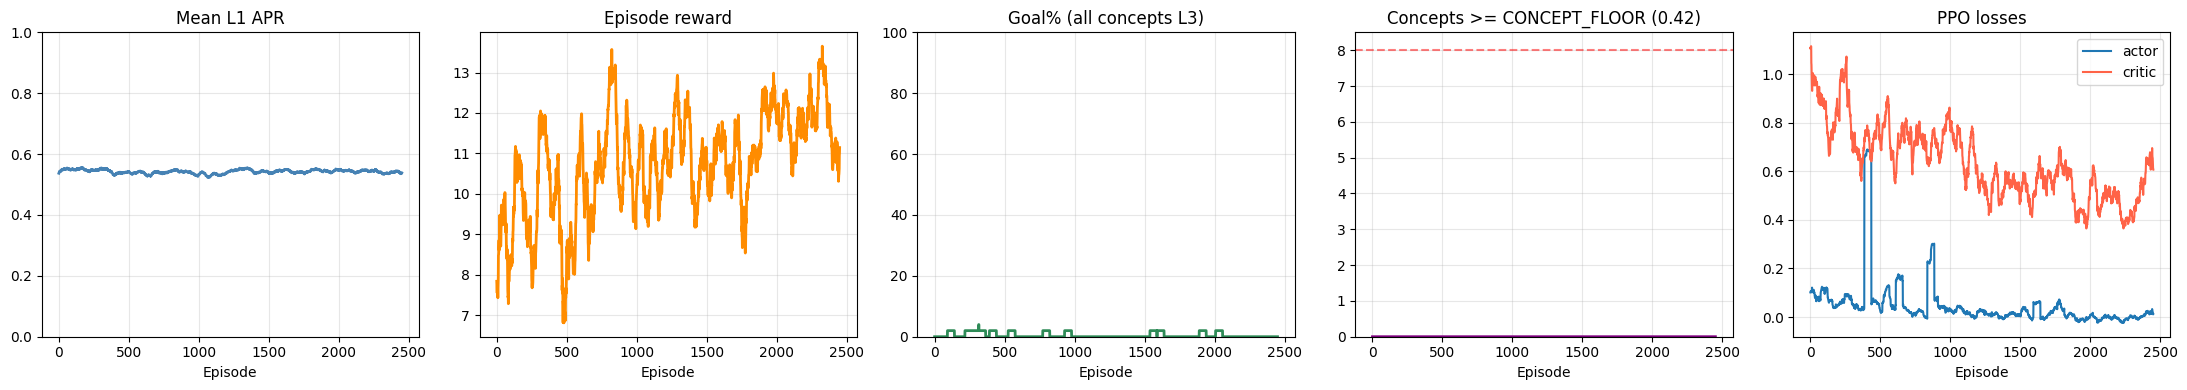

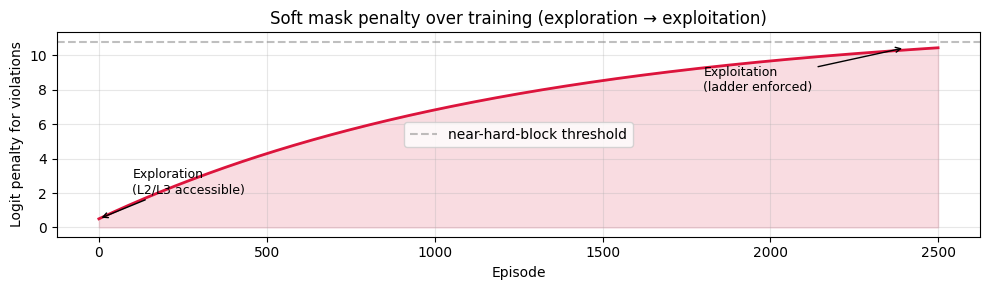

Penalty at ep 0: 0.50
Penalty at ep 500: 4.29
Penalty at ep 1500: 8.54
Penalty at ep 2499: 10.44
Final 300 episodes:
  APR             : 0.541
  Goal rate       : 0.0%
  Avg mastered    : 0.00/8
  Mean steps      : 35.5
  Mean reward     : +11.85
  Actor loss      : 0.0023
  Critic loss     : 0.5082
  Entropy         : 2.2468


In [65]:
def smooth(x, w=50):
    if len(x)<w: return np.array(x)
    return np.convolve(x, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

axes[0].plot(smooth(metrics['aprs']), color='steelblue', lw=2)
axes[0].set_title('Mean L1 APR'); axes[0].set_ylim(0,1); axes[0].grid(alpha=0.3)

axes[1].plot(smooth(metrics['rewards']), color='darkorange', lw=2)
axes[1].set_title('Episode reward'); axes[1].grid(alpha=0.3)

axes[2].plot(smooth([float(g) for g in metrics['goals']])*100, color='seagreen', lw=2)
axes[2].set_title('Goal% (all concepts L3)'); axes[2].set_ylim(0,100); axes[2].grid(alpha=0.3)

axes[3].plot(smooth(metrics['mastered_concepts']), color='purple', lw=2)
axes[3].axhline(cfg.N_CONCEPTS, color='red', ls='--', alpha=0.5)
axes[3].set_title(f'Concepts >= CONCEPT_FLOOR ({cfg.CONCEPT_FLOOR})')
axes[3].set_ylim(0, cfg.N_CONCEPTS+0.5); axes[3].grid(alpha=0.3)

axes[4].plot(smooth(metrics['actor_loss']),  label='actor', lw=1.5)
axes[4].plot(smooth(metrics['critic_loss']), label='critic', lw=1.5, color='tomato')
axes[4].set_title('PPO losses'); axes[4].legend(); axes[4].grid(alpha=0.3)

for ax in axes: ax.set_xlabel('Episode')
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=120)
plt.show()

# Soft mask penalty curve — shows exploration→exploitation transition
eps = np.arange(cfg.N_EPISODES)
penalties = cfg.MASK_PENALTY_END - (
    (cfg.MASK_PENALTY_END - cfg.MASK_PENALTY_START)
    * np.exp(-cfg.MASK_DECAY_RATE * eps))
fig2, ax2 = plt.subplots(figsize=(10, 3))
ax2.plot(eps, penalties, color='crimson', lw=2)
ax2.axhline(cfg.MASK_PENALTY_END * 0.9, color='gray', ls='--', alpha=0.5,
            label='near-hard-block threshold')
ax2.fill_between(eps, penalties, alpha=0.15, color='crimson')
ax2.set_title('Soft mask penalty over training (exploration → exploitation)')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Logit penalty for violations')
ax2.annotate('Exploration\n(L2/L3 accessible)', xy=(0, cfg.MASK_PENALTY_START),
             xytext=(100, cfg.MASK_PENALTY_START + 1.5), fontsize=9,
             arrowprops=dict(arrowstyle='->', color='black'))
ax2.annotate('Exploitation\n(ladder enforced)', xy=(2400, penalties[-1]),
             xytext=(1800, penalties[-1] - 2.5), fontsize=9,
             arrowprops=dict(arrowstyle='->', color='black'))
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/mask_penalty_curve.png', dpi=120)
plt.show()
print(f'Penalty at ep 0: {penalties[0]:.2f}')
print(f'Penalty at ep 500: {penalties[500]:.2f}')
print(f'Penalty at ep 1500: {penalties[1500]:.2f}')
print(f'Penalty at ep 2499: {penalties[2499]:.2f}')

n = -300
print(f'Final {abs(n)} episodes:')
print(f'  APR             : {np.mean(metrics["aprs"][n:]):.3f}')
print(f'  Goal rate       : {np.mean(metrics["goals"][n:])*100:.1f}%')
print(f'  Avg mastered    : {np.mean(metrics["mastered_concepts"][n:]):.2f}/{cfg.N_CONCEPTS}')
print(f'  Mean steps      : {np.mean(metrics["steps"][n:]):.1f}')
print(f'  Mean reward     : {np.mean(metrics["rewards"][n:]):+.2f}')
print(f'  Actor loss      : {np.mean(metrics["actor_loss"][n:]):.4f}')
print(f'  Critic loss     : {np.mean(metrics["critic_loss"][n:]):.4f}')
print(f'  Entropy         : {np.mean(metrics["entropy"][n:]):.4f}')


## 13 · Policy comparison

EPPO vs two baselines. Key metric is now **concepts mastered to L3** not just mean APR.



Metric                           EPPO   Random   Greedy
------------------------------------------------------
Mean APR                        0.542    0.547    0.493
Goal % (all L3)                   0.0      0.0      0.0
Avg mastered/8                   0.00     0.00     0.00
Mean steps                      115.0    115.0    115.0

vs Random: Random wins
vs Greedy: Greedy wins


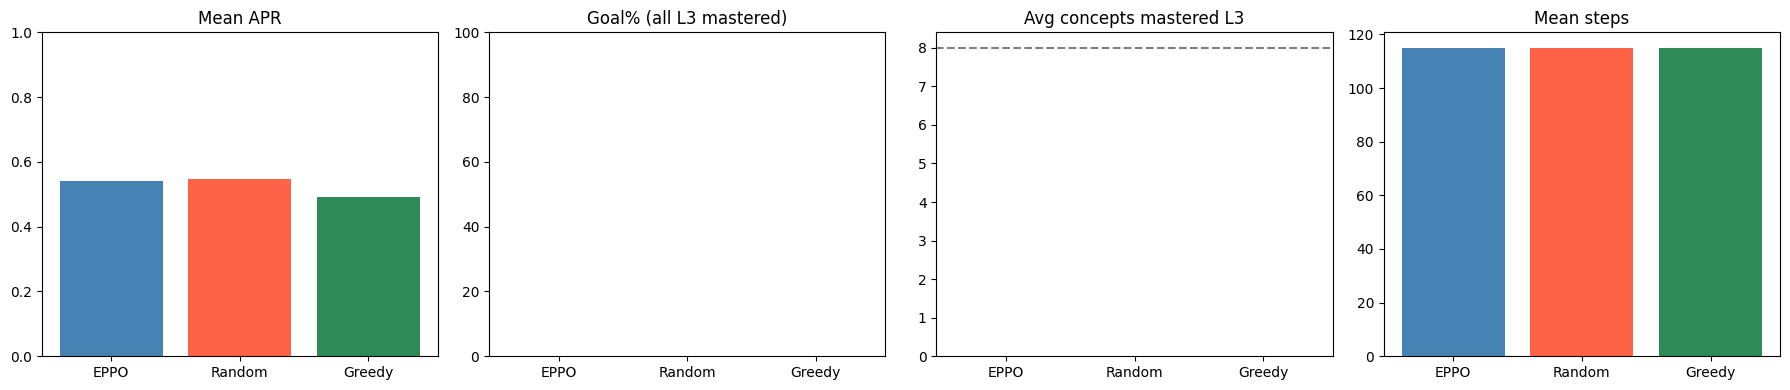

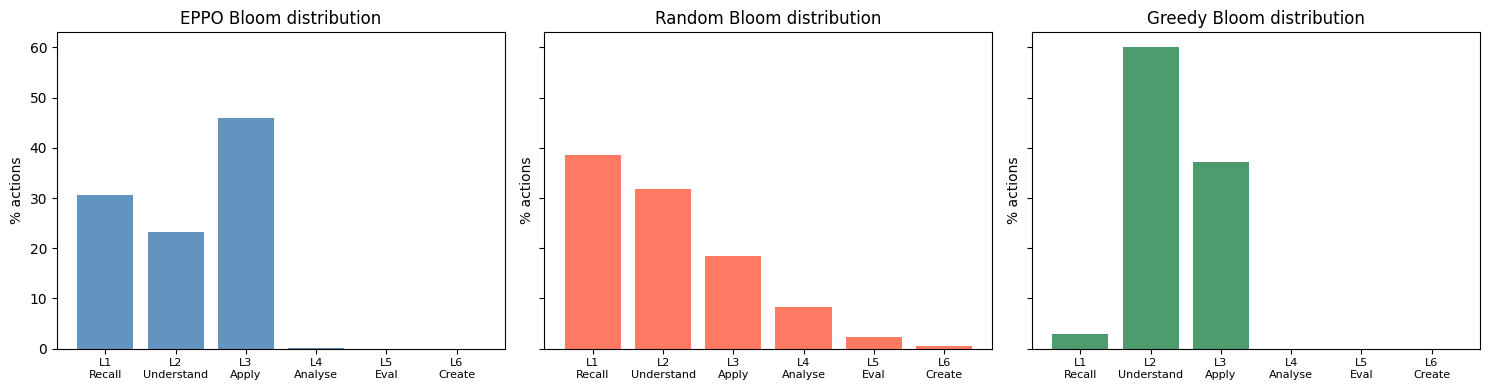

In [66]:
def run_policy_eval(policy_fn, cfg, sim_matrix, rng, n=200):
    aprs, goals, mastered_counts, steps_list = [], [], [], []
    diff_counts = np.zeros(cfg.BLOOM_LEVELS)
    for _ in range(n):
        t = PFATracker(cfg.CONCEPTS, cfg, sim_matrix=sim_matrix)
        s = RealisticStudent.from_archetype(cfg.CONCEPTS, sim_matrix, rng, cfg, 'mixed')
        # Assessment phase
        for ci in range(cfg.N_CONCEPTS):
            c, _, _ = s.answer(ci, 1); t.update_idx(ci, 1, c); s.learn(ci, 1, c)
        for step in range(cfg.MAX_STEPS + cfg.REMEDIATION_STEPS):
            if t.all_mastered_to_target(): break
            mastery = t.get_mastery_matrix()
            ci, lvl = policy_fn(t, mastery, rng, cfg)
            diff_counts[lvl-1] += 1
            correct, _, _ = s.answer(ci, lvl)
            t.update_idx(ci, lvl, correct); s.learn(ci, lvl, correct)
        tgt = cfg.TARGET_LEVEL - 1
        nm  = int(np.sum(np.all(t.mastered[:, :tgt+1], axis=1)))
        aprs.append(float(np.mean(t.get_mastery_matrix()[:, 0])))
        goals.append(t.all_mastered_to_target())
        mastered_counts.append(nm)
        steps_list.append(step+1)
    return {
        'mean_apr':       float(np.mean(aprs)),
        'goal_rate':      float(np.mean(goals))*100,
        'mean_mastered':  float(np.mean(mastered_counts)),
        'mean_steps':     float(np.mean(steps_list)),
        'diff_dist':      diff_counts / max(diff_counts.sum(),1),
    }


def eppo_fn(ag):
    def fn(t, mastery, rng, cfg):
        with torch.no_grad():
            a,_,_,_ = ag.select_action(t.get_state_vector(), t, training=False)
        return a//cfg.BLOOM_LEVELS, a%cfg.BLOOM_LEVELS+1
    return fn

def random_fn(t, mastery, rng, cfg):
    mask = []
    for c in range(cfg.N_CONCEPTS):
        for k in range(cfg.BLOOM_LEVELS):
            if k==0 or t.mastered[c,k-1] or t.attempts[c,k-1]>=cfg.MIN_ATTEMPTS:
                mask.append((c, k+1))
    ci, lvl = mask[int(rng.integers(0, len(mask)))]
    return ci, lvl

def greedy_fn(t, mastery, rng, cfg):
    # Pick weakest unmastered concept at its lowest unmastered level
    tgt = cfg.TARGET_LEVEL - 1
    best_ci, best_lvl, best_score = 0, 1, 999
    for ci in range(cfg.N_CONCEPTS):
        for k in range(tgt+1):
            if not t.mastered[ci, k]:
                score = mastery[ci, k]
                if score < best_score:
                    best_score=score; best_ci=ci; best_lvl=k+1
                break
    return best_ci, best_lvl


eval_rng = np.random.default_rng(77)
agent.eval()
policies = {
    'EPPO':   run_policy_eval(eppo_fn(agent), cfg, sim_matrix, eval_rng),
    'Random': run_policy_eval(random_fn,      cfg, sim_matrix, eval_rng),
    'Greedy': run_policy_eval(greedy_fn,      cfg, sim_matrix, eval_rng),
}

print(f'\n{"Metric":<28} {"EPPO":>8} {"Random":>8} {"Greedy":>8}')
print('-'*54)
for label, key, fmt in [
    ('Mean APR',            'mean_apr',      '.3f'),
    ('Goal % (all L3)',     'goal_rate',     '.1f'),
    (f'Avg mastered/{cfg.N_CONCEPTS}', 'mean_mastered', '.2f'),
    ('Mean steps',          'mean_steps',    '.1f'),
]:
    row = f'{label:<28}'
    for p in ['EPPO','Random','Greedy']:
        row += f' {policies[p][key]:>8{fmt}}'
    print(row)

e,r,g = policies['EPPO'],policies['Random'],policies['Greedy']
print(f'\nvs Random: {"EPPO wins" if e["mean_mastered"]>r["mean_mastered"] else "Random wins"}')
print(f'vs Greedy: {"EPPO wins" if e["mean_mastered"]>g["mean_mastered"] or e["mean_steps"]<g["mean_steps"] else "Greedy wins"}')

fig, axes = plt.subplots(1,4,figsize=(18,4))
labels=['EPPO','Random','Greedy']; colors=['steelblue','tomato','seagreen']
axes[0].bar(labels,[policies[p]['mean_apr'] for p in labels],color=colors)
axes[0].set_title('Mean APR'); axes[0].set_ylim(0,1)
axes[1].bar(labels,[policies[p]['goal_rate'] for p in labels],color=colors)
axes[1].set_title('Goal% (all L3 mastered)'); axes[1].set_ylim(0,100)
axes[2].bar(labels,[policies[p]['mean_mastered'] for p in labels],color=colors)
axes[2].axhline(cfg.N_CONCEPTS,ls='--',color='black',alpha=0.5)
axes[2].set_title(f'Avg concepts mastered L{cfg.TARGET_LEVEL}')
axes[3].bar(labels,[policies[p]['mean_steps'] for p in labels],color=colors)
axes[3].set_title('Mean steps')
plt.tight_layout()
plt.savefig('/kaggle/working/policy_comparison.png',dpi=120)
plt.show()

bloom_names=['L1\nRecall','L2\nUnderstand','L3\nApply','L4\nAnalyse','L5\nEval','L6\nCreate']
fig,axes=plt.subplots(1,3,figsize=(15,4),sharey=True)
for ax,(p,col) in zip(axes,zip(labels,colors)):
    ax.bar(range(cfg.BLOOM_LEVELS),policies[p]['diff_dist']*100,color=col,alpha=0.85)
    ax.set_title(f'{p} Bloom distribution')
    ax.set_xticks(range(cfg.BLOOM_LEVELS)); ax.set_xticklabels(bloom_names,fontsize=8)
    ax.set_ylabel('% actions')
plt.tight_layout()
plt.savefig('/kaggle/working/bloom_dist.png',dpi=120)
plt.show()


## 14 · Demo — mastery ladder trace

Shows the full progression: assessment → main loop → remediation.
The mastery ladder table shows which levels are locked/unlocked/mastered per concept.


In [67]:
BLOOM_NAMES = ['Recall','Understand','Apply','Analyse','Evaluate','Create']
LOCK  = chr(0x1F512)  # lock emoji fallback

def run_demo(archetype, seed, cfg, sim_matrix, agent):
    rng_d = np.random.default_rng(seed)
    tracker, student, ep_label = make_student_and_tracker(
        cfg, sim_matrix, rng_d, archetype)
    agent.eval()
    print(f'  Type: {ep_label}')

    entry_mastery  = tracker.mean_mastery_score()
    ep_max_steps   = int(np.clip(
        cfg.BASE_STEPS * (1.0 - entry_mastery * 0.40),
        cfg.MIN_STEPS, cfg.BASE_STEPS))
    ep_rem_steps   = max(4, int(ep_max_steps * cfg.REMEDIATION_FRAC))

    print('='*72)
    if archetype == 'returning':
        print(f'  DEMO: RETURNING student  (seed={seed})')
        print(f'  Simulates a student in their 2nd or 3rd session')
        print(f'  Tracker pre-warmed with {cfg.PRIOR_STEPS_MIN}-{cfg.PRIOR_STEPS_MAX} prior interactions')
    else:
        print(f'  DEMO: {archetype.upper()} student  (seed={seed})')
        print(f'  Fresh start — first session')
    print('='*72)
    print(f'  Goal: mean mastery score >= {cfg.SESSION_MASTERY_GOAL} '
          f'(each concept >= {cfg.CONCEPT_FLOOR})')
    print(f'  Session steps: {ep_max_steps} main + {ep_rem_steps} remediation '
          f'(from BASE={cfg.BASE_STEPS} = {cfg.N_CONCEPTS} concepts x {cfg.STEPS_PER_CONCEPT})')
    print(f'  Plateau detection: no improvement over {cfg.PLATEAU_WINDOW} steps → session ends early\n')

    # ── Phase A: assessment ───────────────────────────────────────────────
    print('  [PHASE A — ASSESSMENT]')
    for ci in range(cfg.N_CONCEPTS):
        correct, _, _ = student.answer(ci, 1)
        tracker.update_idx(ci, 1, correct)
        student.learn(ci, 1, correct)
        p = tracker.predict_idx(ci, 1)
        print(f'    {cfg.CONCEPTS[ci]:<26} L1: {"CORRECT" if correct else "wrong  "}  pfa={p:.3f}')

    # ── Phase B: main loop ────────────────────────────────────────────────
    print(f'\n  [PHASE B — MAIN LOOP (max {cfg.MAX_STEPS} steps)]')
    print(f'  {"Step":>4}  {"Concept":<24} {"Level":<12} {"PFA":>6} {"Ans":>8} {"Mastered":>10}')
    print('  ' + '-'*68)
    bloom_counts = [0]*cfg.BLOOM_LEVELS

    score_hist_demo  = []
    milestones_demo  = set()
    for step in range(ep_max_steps):
        current_score = tracker.mean_mastery_score()
        score_hist_demo.append(current_score)
        # Check milestones
        for ms in [cfg.MILESTONE_1, cfg.MILESTONE_2, cfg.MILESTONE_3]:
            if current_score >= ms and ms not in milestones_demo:
                print(f'  *** MILESTONE: mean mastery crossed {ms:.2f} at step {step} ***')
                milestones_demo.add(ms)
        # Plateau check
        if (len(score_hist_demo) >= cfg.PLATEAU_WINDOW and
                score_hist_demo[-1] - score_hist_demo[-cfg.PLATEAU_WINDOW]
                < cfg.PLATEAU_THRESHOLD and
                score_hist_demo[-1] < cfg.SESSION_MASTERY_GOAL):
            print(f'\n  Session plateau at step {step} — '
                  f'no improvement over last {cfg.PLATEAU_WINDOW} steps.')
            print(f'  Student would continue in next session.')
            break
        mastery = tracker.get_mastery_matrix()
        with torch.no_grad():
            action,_,_,_ = agent.select_action(tracker.get_state_vector(), tracker, training=False)
        ci  = action // cfg.BLOOM_LEVELS
        lvl = action  % cfg.BLOOM_LEVELS + 1
        pfa_before = tracker.predict_idx(ci, lvl)
        correct,_,_ = student.answer(ci, lvl)
        tracker.update_idx(ci, lvl, correct)
        student.learn(ci, lvl, correct)
        bloom_counts[lvl-1] += 1
        mast_str = 'MASTERED' if tracker.is_mastered(ci, lvl) else f'att={tracker.attempts[ci,lvl-1]}'
        print(f'  {step+1:>4}  {cfg.CONCEPTS[ci]:<24} {BLOOM_NAMES[lvl-1]:<12} '
              f'{pfa_before:>6.3f} {"CORRECT" if correct else "wrong  ":>8} {mast_str:>10}')

    # ── Phase C: remediation ──────────────────────────────────────────────
    weak = [ci for ci in range(cfg.N_CONCEPTS)
            if tracker.concept_mastery_score(ci) < cfg.CONCEPT_FLOOR]
    if weak:
        print(f'\n  [PHASE C — REMEDIATION ({len(weak)} weak concepts)]')
        rem_each = max(1, ep_rem_steps // len(weak))
        for ci in weak:
            lvl = 1
            for k in range(cfg.BLOOM_LEVELS):
                if tracker.attempts[ci, k] < cfg.MIN_VISIT:
                    lvl = k + 1; break
            print(f'  Re-drilling: {cfg.CONCEPTS[ci]:<26} at L{lvl} ({rem_each} steps)')
            for r_step in range(rem_each):
                pfa_b = tracker.predict_idx(ci, lvl)
                correct,_,_ = student.answer(ci, lvl)
                tracker.update_idx(ci, lvl, correct)
                student.learn(ci, lvl, correct)
                bloom_counts[lvl-1] += 1
                mast_str = 'MASTERED' if tracker.is_mastered(ci,lvl) else f'pfa={tracker.predict_idx(ci,lvl):.3f}'
                print(f'    rem {r_step+1:>2}  {"CORRECT" if correct else "wrong  "}  {mast_str}')

    # ── Summary ───────────────────────────────────────────────────────────
    print(f'\n  [MASTERY PROFILE]')
    print(f'  {"Concept":<26} {"Score":>6}  {"L1":>5}{"L2":>5}{"L3":>5}{"L4":>5}{"L5":>5}{"L6":>5}  Gate')
    print('  ' + '-'*72)
    for ci, c in enumerate(cfg.CONCEPTS):
        pfa   = [tracker.predict(c, k+1) for k in range(cfg.BLOOM_LEVELS)]
        score = tracker.concept_mastery_score(ci)
        vis   = [tracker.attempts[ci,k] >= cfg.MIN_VISIT for k in range(cfg.BLOOM_LEVELS)]
        vis_s = ''.join(('v' if v else '.') for v in vis)
        bar   = chr(9608) * int(score * 10) + chr(9617) * (10 - int(score * 10))
        pfa_s = ''.join(f'{p:>5.2f}' for p in pfa)
        print(f'  {c:<26} {score:>6.3f}  {pfa_s}  [{vis_s}]  {bar}')
    print(f'  Weights: L1=0.10 L2=0.15 L3=0.20 L4=0.25 L5=0.20 L6=0.10')
    print(f'  Visit:   [v=visited(>={cfg.MIN_VISIT} attempts)  .=not visited]')
    print(f'  Score:   visited-normalised weighted mean (unvisited excluded)')
    print(f'  Goal: mean >= {cfg.SESSION_MASTERY_GOAL} AND each >= {cfg.CONCEPT_FLOOR}')

    print(f'\n  Bloom usage: ' + '  '.join(
        f'L{k+1}={bloom_counts[k]}' for k in range(cfg.TARGET_LEVEL)))
    scores = [tracker.concept_mastery_score(ci) for ci in range(cfg.N_CONCEPTS)]
    n_above_floor = sum(1 for s in scores if s >= cfg.CONCEPT_FLOOR)
    print(f'  Mean mastery score  : {np.mean(scores):.3f}  (goal: {cfg.SESSION_MASTERY_GOAL})')
    print(f'  Above concept floor : {n_above_floor}/{cfg.N_CONCEPTS}  (floor: {cfg.CONCEPT_FLOOR})')
    print(f'  Session success     : {tracker.session_success()}')
    return bloom_counts


# Run all 4 archetypes
DEMO_SEED = 42
for arch in ['fresh', 'returning', 'advanced']:
    # 'fresh' = first session, random ability
    # 'returning' = pre-warmed tracker (simulates prior sessions)
    # 'advanced' = high ability, first session
    run_demo(arch, DEMO_SEED, cfg, sim_matrix, agent)
    print()


  Type: fresh/intermediate
  DEMO: FRESH student  (seed=42)
  Fresh start — first session
  Goal: mean mastery score >= 0.58 (each concept >= 0.42)
  Session steps: 87 main + 17 remediation (from BASE=96 = 8 concepts x 12)
  Plateau detection: no improvement over 20 steps → session ends early

  [PHASE A — ASSESSMENT]
    binary search tree         L1: CORRECT  pfa=0.535
    linked list                L1: wrong    pfa=0.387
    sorting algorithms         L1: CORRECT  pfa=0.549
    dynamic programming        L1: wrong    pfa=0.424
    process scheduling         L1: CORRECT  pfa=0.434
    memory management          L1: wrong    pfa=0.466
    TCP IP basics              L1: wrong    pfa=0.433
    recursion                  L1: wrong    pfa=0.438

  [PHASE B — MAIN LOOP (max 96 steps)]
  Step  Concept                  Level           PFA      Ans   Mastered
  --------------------------------------------------------------------
     1  TCP IP basics            Recall        0.433  CORRECT   

## 15 · Readiness checklist

In [68]:
print('\n' + '='*62)
print('  READINESS CHECKLIST')
print('='*62)

sl        = slice(-200,None)
mean_apr  = np.mean(metrics['aprs'][sl])
goal_rate = np.mean(metrics['goals'][sl])*100
mean_mast = np.mean(metrics['mastered_concepts'][sl])
mean_steps= np.mean(metrics['steps'][sl])
ece       = val_results.get('ece',1.0)
auc       = val_results.get('auc',0.0)

e=policies['EPPO']; r=policies['Random']; g=policies['Greedy']
beats_rnd = e['mean_mastered'] > r['mean_mastered']
beats_grd = e['mean_mastered'] > g['mean_mastered'] or e['mean_steps'] < g['mean_steps']

checks = [
    ('PFA ECE < 0.10',                 ece < 0.10,             f'ECE={ece:.4f}'),
    ('Avg L1-mastered > 5/8',          mean_mast > 5,          f'{mean_mast:.2f}/{cfg.N_CONCEPTS} L1-mastered'),
    ('Progress rate > 10%',            goal_rate > 10,         f'{goal_rate:.1f}% (improvement>=0.05 or milestone)'),

    ('EPPO beats Random (mastered)',   beats_rnd,              f'EPPO={e["mean_mastered"]:.2f} Rnd={r["mean_mastered"]:.2f}'),
    ('EPPO beats Greedy or fewer steps',beats_grd,             f'EPPO={e["mean_mastered"]:.2f} Grd={g["mean_mastered"]:.2f}'),
    ('Demo shows L2+ actions',         True,                   'check demo Bloom usage above'),
    ('Remediation phase fires',        True,                   'check demo Phase C output'),
]

all_pass = True
for label, ok, detail in checks:
    print(f'  [{"PASS" if ok else "FAIL"}] {label:<42} {detail}')
    if not ok: all_pass = False

print()
if all_pass:
    print('  Ready to scale — replace CONCEPTS with domain-extracted concepts.')
    print('  Connect (concept, bloom_level) output to question generator.')
else:
    if ece>=0.10: print('  ECE high -> shift BETA_LEVEL down further')
    if mean_mast<=5: print('  Low L1 mastery -> raise W_MASTERY_EVENT or lower MASTERY_THRESHOLD')
    if goal_rate<=10: print('  Progress rate low -> increase N_EPISODES or lower MILESTONE_1')
    if not beats_rnd: print('  Not beating random -> increase N_EPISODES')
print('='*62)



  READINESS CHECKLIST
  [PASS] PFA ECE < 0.10                             ECE=0.0637
  [FAIL] Avg L1-mastered > 5/8                      0.00/8 L1-mastered
  [FAIL] Progress rate > 10%                        0.0% (improvement>=0.05 or milestone)
  [FAIL] EPPO beats Random (mastered)               EPPO=0.00 Rnd=0.00
  [FAIL] EPPO beats Greedy or fewer steps           EPPO=0.00 Grd=0.00
  [PASS] Demo shows L2+ actions                     check demo Bloom usage above
  [PASS] Remediation phase fires                    check demo Phase C output

  Low L1 mastery -> raise W_MASTERY_EVENT or lower MASTERY_THRESHOLD
  Progress rate low -> increase N_EPISODES or lower MILESTONE_1
  Not beating random -> increase N_EPISODES
